# Flagging Vendor Invoices for Manual Review

## Objective

The goal of this project is to predict whether a vendor invoice should be **flagged for manual review**.

The model checks invoice details such as **cost, freight, and delivery information** to identify invoices that may need human verification.

### Why is this important?

- Manual invoice checking takes a lot of time.
- Some invoices may contain unusual freight charges or pricing errors.
- Delivery issues or incorrect invoice values can increase financial risk.
- An automated system can identify suspicious invoices quickly.
- This helps finance teams focus only on high-risk invoices while processing normal invoices faster.

In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect(
    r"C:\Users\sanid\Downloads\invoice intelligence\data\inventory.db"
)

In [3]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table'",
    conn
)

for table in tables["name"]:
    print(f"Table Name: {table}")
    display(pd.read_sql(f"SELECT * FROM {table} LIMIT 5", conn))

Table Name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table Name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table Name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table Name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table Name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


## Create Invoice-Level Summary

The original dataset contains multiple rows for each purchase order because one invoice can have many products.

For this project, we need one record for each purchase order.

So, we create a new table that contains useful information such as:

- Purchase Order Number
- Total number of brands
- Total quantity
- Total invoice amount
- Average receiving delay

This summarized data will be used to build the machine learning model.

In [4]:
purchase_agg_df = pd.read_sql_query("""
SELECT
    p.PONumber,
    COUNT(DISTINCT p.Brand) AS total_brands,
    SUM(p.Quantity) AS total_item_quantity,
    SUM(p.Dollars) AS total_item_dollars,
    AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
FROM purchases p
GROUP BY p.PONumber
""", conn)

purchase_agg_df.head()

,PONumber,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271


In [5]:
purchase_agg_df.shape

(5543, 5)

## Load Vendor Invoice Data

Now, we load the required information from the `vendor_invoice` table.

This data contains invoice details such as:

- Purchase Order Number
- Invoice Quantity
- Invoice Amount
- Freight Cost
- Days between Purchase Order and Invoice
- Days taken to make the payment

These features will later be combined with the purchase summary to build the machine learning model.

In [6]:
vendor_invoice_df = pd.read_sql_query("""
SELECT
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay
FROM vendor_invoice vi
""", conn)

vendor_invoice_df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay
0,8124,6,214.26,3.47,14.0,43.0
1,8137,15,140.55,8.57,16.0,45.0
2,8169,5,106.60,4.61,16.0,38.0
3,8106,10100,137483.78,2935.20,23.0,24.0
4,8170,1935,15527.25,429.20,14.0,36.0
...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0
5539,13661,4617,37300.48,186.50,18.0,39.0
5540,13643,9848,202815.78,932.95,11.0,33.0
5541,13602,24747,149007.56,819.54,14.0,36.0


## Combine Purchase and Invoice Data

Now, we combine the purchase summary with the vendor invoice data.

We use a **LEFT JOIN** on the **Purchase Order Number (PONumber)** so that each invoice also contains the purchase-related information.

This creates a single dataset with all the features required for machine learning.

In [7]:
final_df = pd.read_sql_query("""
WITH purchase_agg AS (
    SELECT
        p.PONumber,
        COUNT(DISTINCT p.Brand) AS total_brands,
        SUM(p.Quantity) AS total_item_quantity,
        SUM(p.Dollars) AS total_item_dollars,
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
    FROM purchases p
    GROUP BY p.PONumber
)

SELECT
    vi.PONumber,
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay

FROM vendor_invoice vi

LEFT JOIN purchase_agg pa
ON vi.PONumber = pa.PONumber

""", conn)

final_df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [8]:
final_df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [9]:
final_df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

## Create the Target Variable

Machine Learning models need a **target variable** to learn from.

In this project, we create a new column called **`flag_invoice`**.

The invoice is flagged (`1`) if:

- The invoice amount is very different from the total purchase amount.
- The average receiving delay is greater than **10 days**.

Otherwise, the invoice is marked as **0**.

- **1** → Invoice needs manual review.
- **0** → Invoice is normal.

In [10]:
def create_invoice_risk_label(row):

    # Invoice total mismatch with item-level total
    if abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5:
        return 1

    # Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1

    return 0


final_df["flag_invoice"] = final_df.apply(
    create_invoice_risk_label,
    axis=1
)

final_df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

## Visualize the Target Variable

Now, let's see how many invoices are **flagged** and **not flagged**.

A bar chart helps us understand the distribution of the target variable.

- **0** → Normal Invoice
- **1** → Flagged Invoice

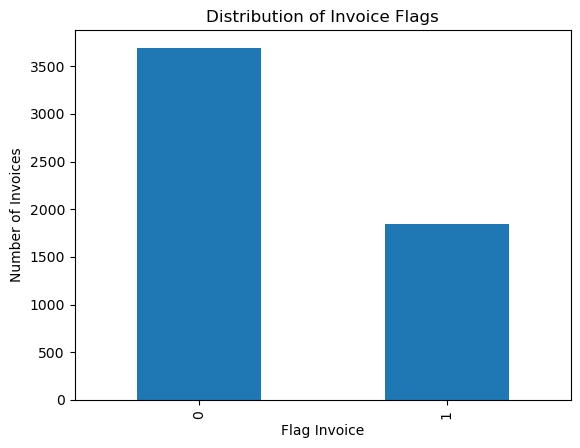

In [11]:
final_df["flag_invoice"].value_counts().plot(kind="bar")

plt.xlabel("Flag Invoice")
plt.ylabel("Number of Invoices")
plt.title("Distribution of Invoice Flags")

plt.show()

## Correlation Heatmap

Before training the machine learning model, let's check how the numerical features are related to each other.

A correlation heatmap helps us understand:

- Which features are strongly related.
- Which features have little or no relationship.
- Which features may be useful for predicting the target variable.
  

In [12]:
final_df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.013423,0.049442,0.059221,-0.042362,0.564946
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.566394,0.706117,0.668171,0.000519,0.032783
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.536952,0.667666,0.679537,0.004694,0.037994
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.536381,0.656616,0.670768,0.015645,0.037759
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.009519,0.005543,0.007931,0.515538,0.183115
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.020336,0.016203,0.015610,-0.029403,-0.005289
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,1.000000,0.783825,0.753092,0.000496,0.008961
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.016203,0.783825,1.000000,0.963831,-0.014016,0.032783
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.015610,0.753092,0.963831,1.000000,-0.014251,0.037994
avg_receiving_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,-0.029403,0.000496,-0.014016,-0.014251,1.000000,0.311667


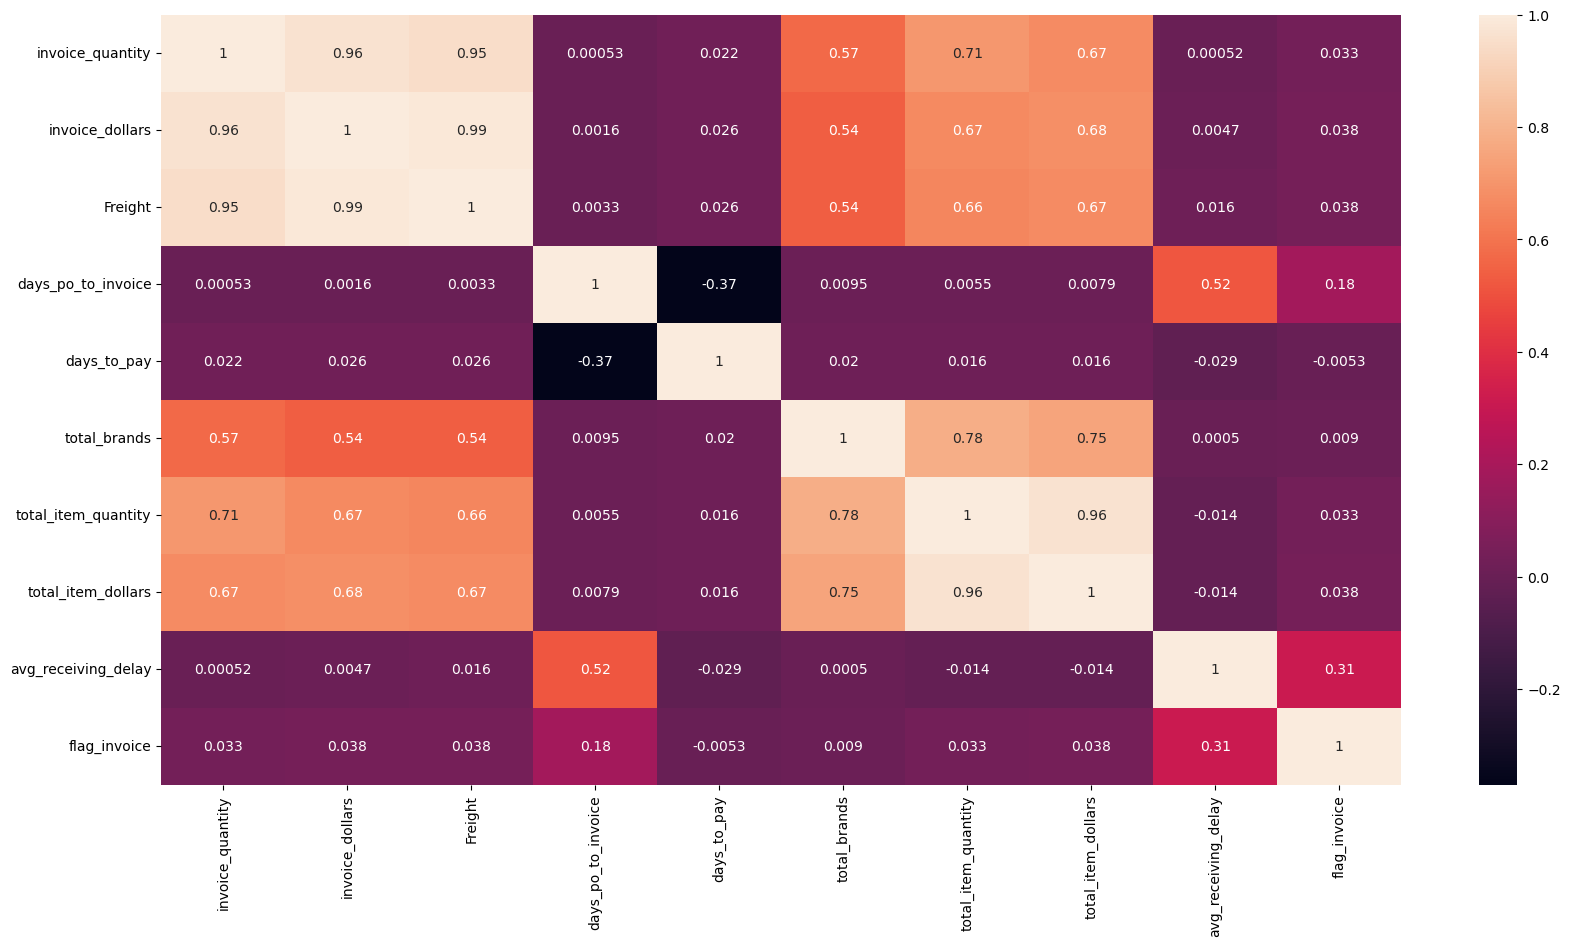

In [13]:
plt.figure(figsize=(20, 10))

sns.heatmap(
    final_df.iloc[:,1:].corr(numeric_only=True),
    annot=True
)

plt.show()

## Feature Significance Test

Now, we compare the **flagged invoices** and **normal invoices**.

We use an **Independent T-Test** to check whether each feature shows a significant difference between the two groups.

The results help us identify which features are useful for predicting whether an invoice should be flagged.

Decision Rule:

- **p-value < 0.05** → Significant Feature
- **p-value ≥ 0.05** → Not Significant

In [14]:
flagged = final_df[final_df["flag_invoice"] == 1]
normal = final_df[final_df["flag_invoice"] == 0]

significant_features = []
non_significant_features = []
results = []

metrics = [
    "invoice_quantity",
    "invoice_dollars",
    "Freight",
    "days_po_to_invoice",
    "days_to_pay",
    "total_brands",
    "total_item_quantity",
    "total_item_dollars",
    "avg_receiving_delay",
]

In [15]:
from scipy.stats import ttest_ind

for metric in metrics:

    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:

        significant_features.append(metric)

        results.append({
            "metric": metric,
            "flagged_mean": round(flagged_mean, 2),
            "normal_mean": round(normal_mean, 2),
            "p_value": round(p_value, 3)
        })

    else:
        non_significant_features.append(metric)

In [16]:
non_significant_features

['days_to_pay', 'total_brands']

In [17]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_receiving_delay']

In [18]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(334.02),
  'normal_mean': np.float64(276.89),
  'p_value': np.float64(0.008)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(17.23),
  'normal_mean': np.float64(16.02),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_value': np.float64(0.021)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_value': np.float64(0.008)},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': np.float64(8.47),
  'normal_mean': np.float64(7.27),
  'p_value': np.float64(0.0)}]

# Prepare Data for Machine Learning

Now, we prepare the dataset for training the classification models.

We select the important features as input (**X**) and use **flag_invoice** as the target variable (**y**).

The selected features will help the model predict whether an invoice should be flagged for manual review.

In [19]:
# Input Features
X = final_df[[
    "invoice_quantity",
    "invoice_dollars",
    "Freight",
    "total_brands",
    "total_item_quantity",
    "days_po_to_invoice",
    "total_item_dollars"
]]

# Target Variable
y = final_df["flag_invoice"]

# Split and Scale the Data

The dataset is divided into:

- **80% Training Data**
- **20% Testing Data**

After splitting the data, we standardize the features using **StandardScaler**.

Feature scaling ensures that all numerical features are on a similar scale, which helps improve the performance of machine learning models.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [28]:
X_test.shape

(1109, 7)

In [29]:
X_train.shape

(4434, 7)

In [30]:
X.describe().round()

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,6059.0,58073.0,296.0,41.0,6059.0,16.0,58073.0
std,14453.0,140234.0,714.0,77.0,14453.0,3.0,140234.0
min,1.0,4.0,0.0,1.0,1.0,9.0,4.0
25%,83.0,968.0,5.0,3.0,83.0,14.0,968.0
50%,423.0,4765.0,25.0,7.0,423.0,16.0,4765.0
75%,5100.0,44587.0,230.0,46.0,5100.0,19.0,44587.0
max,141660.0,1660436.0,8468.0,807.0,141660.0,23.0,1660436.0


In [31]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Classification Models

In this project, we train three different classification models:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

Training multiple models allows us to compare their performance and choose the best model for predicting invoice risk.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [33]:
# Logistic Regression
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

# Decision Tree Classifier
model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

# Random Forest Classifier
model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

# Evaluate Model Performance

After training the models, we evaluate their performance using the test dataset.

The models are compared using the following evaluation metrics:

- Accuracy
- Precision
- Recall
- F1 Score

These metrics help us determine which model performs best for identifying invoices that require manual review.

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

def evaluate_model(model, X_test, y_test, model_name):

    preds = model.predict(X_test)

    accuracy = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    print(f"\n{model_name} Performance:")
    print(f"Accuracy : {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall   : {recall:.2f}")
    print(f"F1 Score : {f1:.2f}")

# Analyze Feature Importance

Finally, we analyze the feature importance of the Random Forest Classifier.

Feature importance shows how much each feature contributes to the model's predictions.

Features with higher importance have a greater influence on deciding whether an invoice should be flagged.

In [35]:
evaluate_model(
    model1,
    X_test_scaled,
    y_test,
    "Logistic Regression"
)

evaluate_model(
    model2,
    X_test_scaled,
    y_test,
    "Decision Tree Classifier"
)

evaluate_model(
    model3,
    X_test_scaled,
    y_test,
    "Random Forest Classifier"
)


Logistic Regression Performance:
Accuracy : 0.66
Precision: 0.56
Recall   : 0.06
F1 Score : 0.11

Decision Tree Classifier Performance:
Accuracy : 0.81
Precision: 0.74
Recall   : 0.71
F1 Score : 0.72

Random Forest Classifier Performance:
Accuracy : 0.88
Precision: 0.94
Recall   : 0.68
F1 Score : 0.79


## Feature Importance

After training the Random Forest Classifier, we can check which features have the greatest impact on predicting whether an invoice should be flagged.

Feature importance tells us how much each feature contributes to the model's decision.

A higher importance value means the feature has a stronger influence on the prediction.

In [36]:
model3.feature_importances_

array([0.15137936, 0.15124851, 0.14480642, 0.07920458, 0.17669413,
       0.07717963, 0.21948736])

In [37]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
)

feature_importance

,feature,importance
6,total_item_dollars,0.219487
4,total_item_quantity,0.176694
0,invoice_quantity,0.151379
1,invoice_dollars,0.151249
2,Freight,0.144806
3,total_brands,0.079205
5,days_po_to_invoice,0.077180


# Hyperparameter Tuning using GridSearchCV

After training the Random Forest Classifier, we can further improve its performance by tuning its hyperparameters.

Hyperparameter tuning helps us find the best combination of model parameters automatically.

In this project, we use **GridSearchCV**, which tests different parameter combinations and selects the one that gives the best performance.

In [41]:
X = final_df[[
    "invoice_quantity",
    "invoice_dollars",
    "Freight",
    "total_item_quantity",
    "total_item_dollars"
]]

y = final_df["flag_invoice"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model3 = RandomForestClassifier(random_state=42)

model3.fit(X_train_scaled, y_train)

evaluate_model(
    model3,
    X_test_scaled,
    y_test,
    "Random Forest Classifier"
)


Random Forest Classifier Performance:
Accuracy : 0.88
Precision: 0.94
Recall   : 0.72
F1 Score : 0.81


## Apply GridSearchCV

Now, we use **GridSearchCV** to search for the best Random Forest parameters.

GridSearchCV trains the model using different parameter combinations and selects the one with the highest evaluation score.

This helps improve the model's performance without manually trying different values.

In [46]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}


In [47]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

scorer = make_scorer(f1_score)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

evaluate_model(
    grid_search,
    X_test_scaled,
    y_test,
    "Random Forest Classifier"
)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Random Forest Classifier Performance:
Accuracy : 0.89
Precision: 0.96
Recall   : 0.71
F1 Score : 0.81


# Compare Model Performance Using Confusion Matrix

After applying GridSearchCV, we compare the tuned Random Forest model with the original Random Forest model.

A **Confusion Matrix** shows how many predictions were correct and incorrect for each class.

This helps us understand whether hyperparameter tuning improved the model's performance.

In [48]:
from sklearn.metrics import confusion_matrix

## Confusion Matrix for Tuned Random Forest

In [49]:
confusion_matrix(
    y_test,
    grid_search.predict(X_test_scaled)
)

array([[713,  12],
       [112, 272]])

## Confusion Matrix for Original Random Forest

In [50]:
confusion_matrix(
    y_test,
    model3.predict(X_test_scaled)
)

array([[706,  19],
       [109, 275]])

## Best Hyperparameters

In [51]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}

## Explanation

The confusion matrix compares the actual invoice labels with the predicted labels.

It contains four values:

- **True Positive (TP):** Flagged invoices correctly identified.
- **True Negative (TN):** Normal invoices correctly identified.
- **False Positive (FP):** Normal invoices incorrectly flagged.
- **False Negative (FN):** Flagged invoices incorrectly classified as normal.

Finally, **GridSearchCV** provides the best combination of Random Forest parameters, which helps improve the model's prediction performance.